# Normalized Performance Comparison (2010–Today)

In this notebook, we compare the performance of a selected stock (**TICKER**) and the **S&P 500** by normalizing both price series to **0% at the start date**.

This allows us to:
- Compare relative performance over time
- See which asset outperformed since 2010
- Remove scale differences between assets


In [1]:
# --- Imports ---
from src.technical_setup import *


c:\Users\Linus\Desktop\Python\src\technical_setup.py:22: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download(TICKER, start=START_DATE)["Close"]
[*********************100%***********************]  1 of 1 completed
c:\Users\Linus\Desktop\Python\src\technical_setup.py:23: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500 = yf.download("^GSPC", start=START_DATE)["Close"]
[*********************100%***********************]  1 of 1 completed


## Function: Plot Normalized Performance

This function normalizes two price series to 0% at the start date and plots their performance over time.
It can also save the resulting figure.


In [2]:
def plot_normalized_performance(asset1, asset2, label1="S&P 500", label2="Stock",
                                title="Normalized Performance Comparison (2010–Today)",
                                save_path=None):
    """
    Plots normalized performance of two assets starting at 0%.

    Parameters
    ----------
    asset1 : pd.Series
        First asset price series
    asset2 : pd.Series
        Second asset price series
    label1 : str
        Label for the first asset
    label2 : str
        Label for the second asset
    title : str
        Plot title
    save_path : str, optional
        Path to save the figure (e.g., 'figures/plot.png'). If None, the figure is not saved.
    """
    # Normalize performance to 0% at the start
    norm_asset1 = (asset1 / asset1.iloc[0] - 1) * 100
    norm_asset2 = (asset2 / asset2.iloc[0] - 1) * 100

    # Create plot
    fig, ax = plt.subplots(figsize=(15, 8))
    ax.plot(norm_asset1, label=label1, color="blue")
    ax.plot(norm_asset2, label=label2, color="red")

    # Styling
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.set_title(title, fontsize=14)
    ax.set_ylabel("Performance (%)", fontsize=12)
    ax.set_xlabel("Date", fontsize=12)
    ax.legend()

    plt.show()

    # Save figure if requested
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, dpi=150, bbox_inches="tight")


## Example Usage

We now apply the function to compare the normalized performance of the selected stock and the S&P 500.
The chart is also saved to the `figures/` folder.


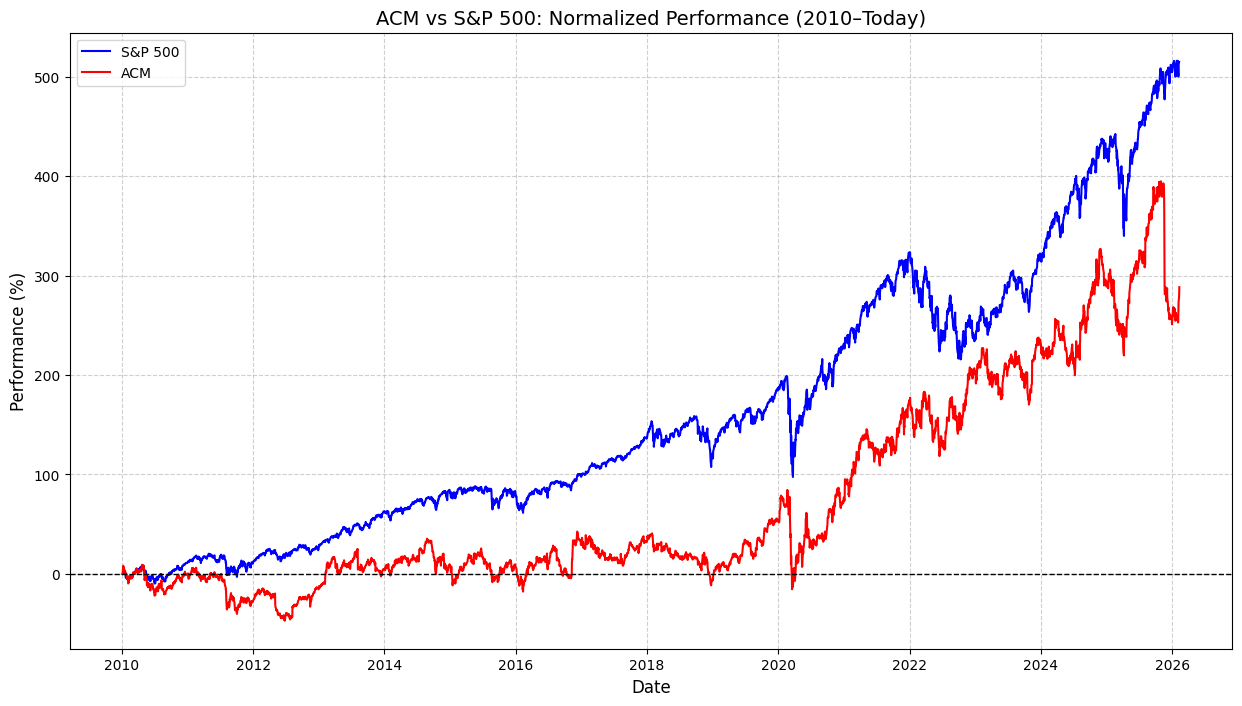

In [3]:
plot_normalized_performance(
    asset1=sp500,
    asset2=stock,
    label1="S&P 500",
    label2=TICKER,
    title=f"{TICKER} vs S&P 500: Normalized Performance (2010–Today)",
    save_path=f"figures/{TICKER}_normalized_performance.png"
)
